In [4]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [3]:
# ---------- STEP 1: Data transforms ----------
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])


transform = transforms.Compose([
    transforms.Resize((380, 380)),  # ⚠️ Required for EfficientNet-B4
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ✅ Standard for pretrained EfficientNet
                         std=[0.229, 0.224, 0.225])
])



In [4]:
import os
import glob
import re
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch

class SequenceDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None, sequence_length=10):
        self.samples = []
        self.transform = transform
        self.sequence_length = sequence_length

        data_dirs = {'real': real_dir, 'fake': fake_dir}
        class_map = {'real': 0, 'fake': 1}

        for label_name, label_dir in data_dirs.items():
            video_dict = defaultdict(list)
            for path in glob.glob(os.path.join(label_dir, '*.jpg')):
                filename = os.path.basename(path)
                match = re.match(r'(.+?)_frame\d+', filename)
                if match:
                    video_id = match.group(1)
                    video_dict[video_id].append(path)

            for video_id, frame_paths in video_dict.items():
                frame_paths = sorted(frame_paths)
                if len(frame_paths) >= sequence_length:
                    for i in range(0, len(frame_paths) - sequence_length + 1, sequence_length):
                        seq = frame_paths[i:i + sequence_length]
                        self.samples.append((seq, class_map[label_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, label = self.samples[idx]
        frames = []

        for path in frame_paths:
            image = Image.open(path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            frames.append(image)

        frames_tensor = torch.stack(frames)  # Shape: [T, 3, H, W]
        return frames_tensor, torch.tensor(label, dtype=torch.float32)


In [5]:
sequence_length = 6    # or any number of frames per sequence




real_dir = "/kaggle/input/ff-dfd-40k/real_FF_DFD_mix/real_FF_DFD_mix"
fake_dir = "/kaggle/input/ff-dfd-40k/fake_FF_DFD_mix/fake_FF_DFD_mix"

dataset = SequenceDataset(real_dir=real_dir, fake_dir=fake_dir, transform=transform, sequence_length=sequence_length)

train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=4, num_workers=2)


In [6]:
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
import torch.nn as nn
import torch

class FaceSwapDetector(nn.Module):
    def __init__(self, hidden_size=256, num_layers=1, bidirectional=True):
        super(FaceSwapDetector, self).__init__()
        weights = EfficientNet_B4_Weights.IMAGENET1K_V1
        base_model = efficientnet_b4(weights=weights)

        # Freeze early layers: features[0] to features[4]
        for idx, layer in enumerate(base_model.features):
            if idx <= 4:  # Freeze stem + low-level MBConv layers
                for param in layer.parameters():
                    param.requires_grad = False
            else:
                for param in layer.parameters():
                    param.requires_grad = True

        self.feature_extractor = nn.Sequential(
            base_model.features,
            base_model.avgpool  # [B*T, 1792, 1, 1]
        )

        self.hidden_size = hidden_size
        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=1792,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        self.attention_layer = nn.Sequential(
            nn.Linear(hidden_size * self.num_directions, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size * self.num_directions, 1)
        )

    def forward(self, x):  # [B, T, 3, 224, 224]
        B, T, C, H, W = x.size()
        x = x.view(B * T, C, H, W)

        features = self.feature_extractor(x)  # [B*T, 1792, 1, 1]
        features = features.view(B, T, -1)    # [B, T, 1792]

        lstm_out, _ = self.lstm(features)
        attn_scores = self.attention_layer(lstm_out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context_vector = torch.sum(attn_weights * lstm_out, dim=1)

        out = self.classifier(context_vector)
        return out


In [7]:
from collections import Counter
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FaceSwapDetector()  # after LSTM-modified class
model.to(device)



criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=1e-4  # You can tune this value
)






# model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:00<00:00, 104MB/s] 


In [ ]:


import torch
torch.cuda.empty_cache()


In [10]:
for batch in train_loader:
    x, y = batch
    print("Input shape:", x.shape)   # Should be [B, T, 3, 224, 224]
    print("Labels:", y.shape)        # Should be [B]
    out = model(x.to(device))
    print("Output:", out.shape)      # Should be [B, 1]
    break


Input shape: torch.Size([4, 6, 3, 380, 380])
Labels: torch.Size([4])
Output: torch.Size([4, 1])


In [ ]:
print("hele")

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Tracking metrics
train_losses = []
train_accuracies = []
val_accuracies = []
val_losses = []
val_precisions = []
val_recalls = []
val_f1s = []

# For saving best model
best_f1 = 0.0
epochs_no_improve = 0
early_stop_patience = 5
early_stop = False

for epoch in range(50):
    if early_stop:
        print(f"⏹️ Early stopping at epoch {epoch}")
        break

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        inputs, labels = inputs.to(device), labels.to(device).float()
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_train_acc)

    print(f"Epoch {epoch+1}, Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_train_acc:.2f}%")

    # ---------- Validation ----------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float()
            outputs = model(inputs).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy() > 0.5)
            all_labels.extend(labels.detach().cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    val_precisions.append(precision)
    val_recalls.append(recall)
    val_f1s.append(f1)

    print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

    # ---------- Scheduler ----------
    current_lr = optimizer.param_groups[0]['lr']
    print(f"🔄 Current Learning Rate: {current_lr:.6f}")
    scheduler.step(avg_val_loss)

    # ---------- Early Stopping ----------
    if f1 > best_f1:
        best_f1 = f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "bilstm_attention_faceswap_10fps.pth")
        print("✅ Best model saved (F1 improved).")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement in F1 for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= early_stop_patience:
            early_stop = True
            print("⛔ Early stopping triggered.")

print("🎯 Training Complete.")

Epoch 1:   0%|          | 0/2225 [00:00<?, ?it/s]

Epoch 1, Train Loss: 0.5396, Train Accuracy: 71.05%
Validation Loss: 0.2193, Validation Accuracy: 91.27%
Precision: 0.8633, Recall: 0.9768, F1 Score: 0.9165
🔄 Current Learning Rate: 0.005000
✅ Best model saved (F1 improved).


Epoch 2:   0%|          | 0/2225 [00:00<?, ?it/s]

Epoch 2, Train Loss: 0.1828, Train Accuracy: 92.94%
Validation Loss: 0.1167, Validation Accuracy: 96.26%
Precision: 0.9305, Recall: 0.9984, F1 Score: 0.9633
🔄 Current Learning Rate: 0.005000
✅ Best model saved (F1 improved).


Epoch 3:   0%|          | 0/2225 [00:00<?, ?it/s]

...

Epoch 20, Train Loss: 0.0075, Train Accuracy: 99.73%
Validation Loss: 0.0346, Validation Accuracy: 99.06%
Precision: 0.9834, Recall: 0.9976, F1 Score: 0.9905
🔄 Current Learning Rate: 0.001250
⚠️ No improvement in F1 for 3 epoch(s).


Epoch 21:   0%|          | 0/2225 [00:00<?, ?it/s]

Epoch 21, Train Loss: 0.0056, Train Accuracy: 99.79%
Validation Loss: 0.0335, Validation Accuracy: 99.17%
Precision: 0.9842, Recall: 0.9992, F1 Score: 0.9917
🔄 Current Learning Rate: 0.000625
⚠️ No improvement in F1 for 4 epoch(s).


Epoch 22:   0%|          | 0/2225 [00:00<?, ?it/s]

Epoch 22, Train Loss: 0.0045, Train Accuracy: 99.88%
Validation Loss: 0.0397, Validation Accuracy: 99.17%
Precision: 0.9842, Recall: 0.9992, F1 Score: 0.9917
🔄 Current Learning Rate: 0.000625
⚠️ No improvement in F1 for 5 epoch(s).
⛔ Early stopping triggered.
⏹️ Early stopping at epoch 22
🎯 Training Complete.


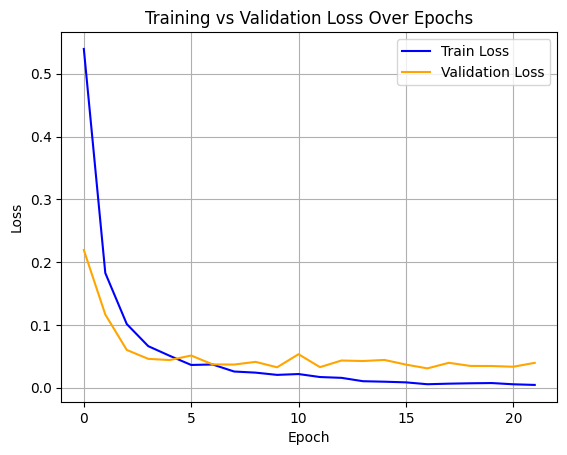

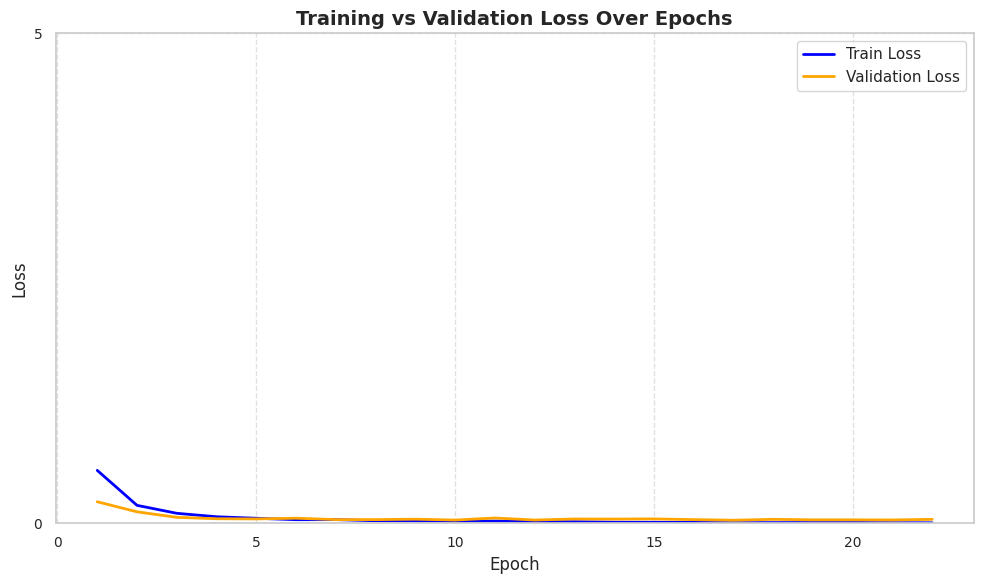

In [9]:
# ---------- STEP 7: Train vs Validation Loss Plot ----------
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

# Example data
# train_losses = [...]
# val_losses = [...]

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

# Plot without markers
plt.plot(epochs, train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(epochs, val_losses, label='Validation Loss', color='orange', linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training vs Validation Loss Over Epochs", fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)

# Set y-ticks with step of 5
max_loss = max(max(train_losses), max(val_losses))
top_tick = int(np.ceil(max_loss / 5.0)) * 5
plt.yticks(np.arange(0, top_tick + 5, 5))
plt.ylim(0, top_tick)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))

epochs = range(len(train_accuracies))

# Plot lines
plt.plot(epochs, train_accuracies, label='Train Accuracy', color='green')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='purple')

# Labels & Title
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Validation Accuracy")

# Ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 100)

# Legend & Grid
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


NameError: name 'train_accuracies' is not defined

<Figure size 800x500 with 0 Axes>

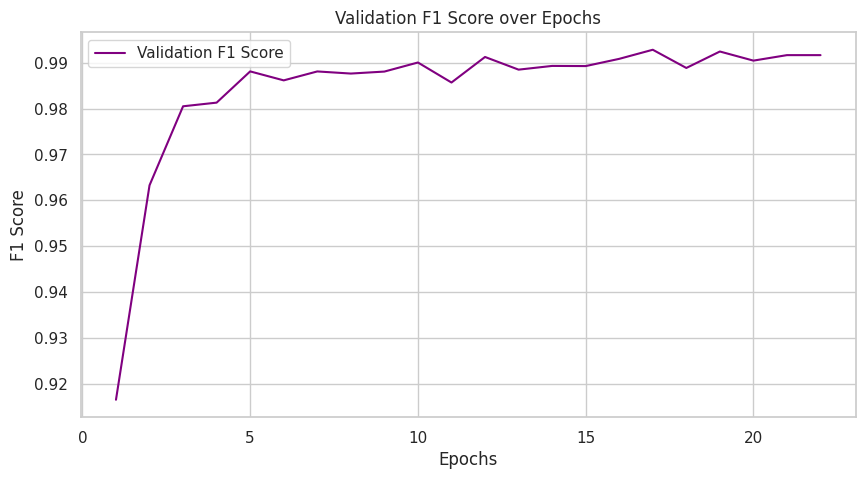

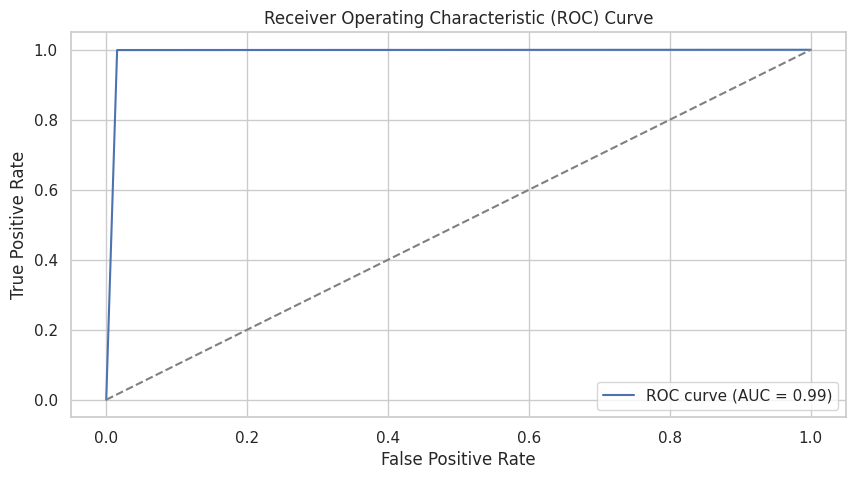

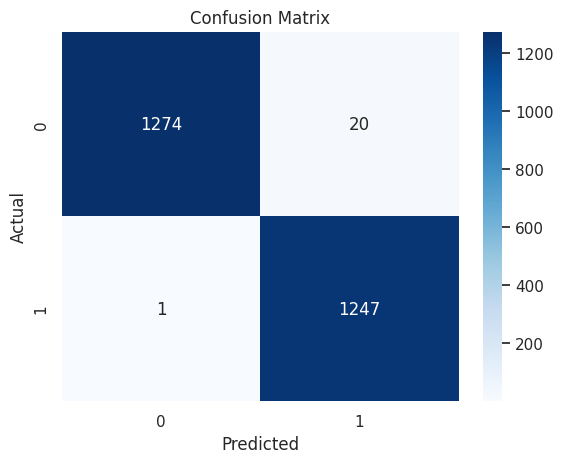

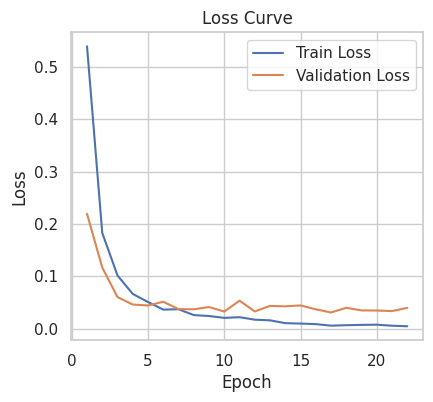

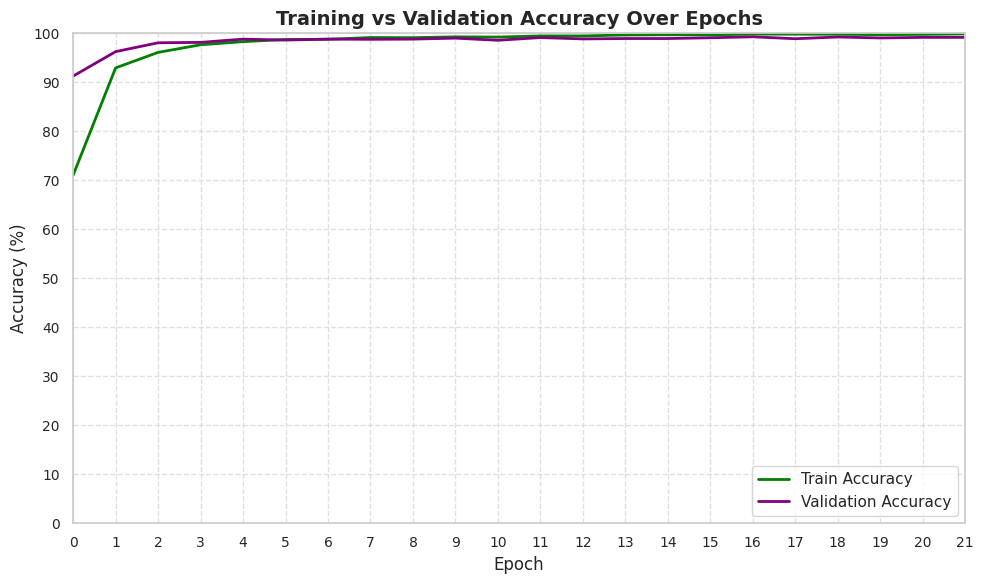

🔧 Trainable Parameters: 20,484,062
🧱 Non-trainable Parameters: 1,329,260
🧮 Total Parameters: 21,813,322


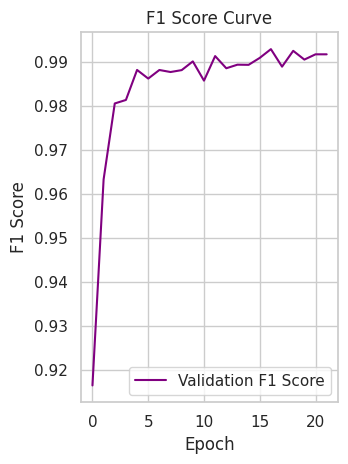

In [10]:
# ---------- Plotting F1 Score, ROC Curve, AUC ----------

from sklearn.metrics import roc_curve, auc, confusion_matrix


# Plot F1 Score over epochs
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(val_f1s)+1), val_f1s, label="Validation F1 Score", color="purple")
plt.xlabel("Epochs")
plt.ylabel("F1 Score")
plt.title("Validation F1 Score over Epochs")
plt.legend()
plt.show()

# Compute ROC Curve and AUC
fpr, tpr, _ = roc_curve(all_labels, all_preds)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# ---------- Confusion Matrix ----------
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------- Loss Curve ----------
epochs = list(range(1, len(train_losses)+1))
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()



# ---------- STEP 8: Train vs Validation Accuracy Plot ----------
plt.figure(figsize=(10, 6))

# Epochs range (starting from 0)
epochs = range(0, len(train_accuracies))

# Plot Accuracy
plt.plot(epochs, train_accuracies, label='Train Accuracy', color='green', linewidth=2)
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='purple', linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Training vs Validation Accuracy Over Epochs", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)

# Set y-ticks and x-ticks
plt.yticks(np.arange(0, 105, 10))
plt.xticks(np.arange(0, len(train_accuracies), step=1))
plt.xlim(0, len(train_accuracies) - 1)
plt.ylim(0, 100)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


# Count parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"🔧 Trainable Parameters: {trainable_params:,}")
print(f"🧱 Non-trainable Parameters: {non_trainable_params:,}")
print(f"🧮 Total Parameters: {trainable_params + non_trainable_params:,}")




# ---------- F1 Score Curve ----------
plt.subplot(1, 2, 2)
plt.plot(epochs, val_f1s, label='Validation F1 Score', color='purple')
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))

epochs = range(len(train_accuracies))

# Plot lines
plt.plot(epochs, train_accuracies, label='Train Accuracy', color='green')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='purple')

# Labels & Title
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Validation Accuracy")

# Ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 100)

# Legend & Grid
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


NameError: name 'train_accuracies' is not defined

<Figure size 800x500 with 0 Axes>

In [11]:
import time
from sklearn.metrics import classification_report

model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

start_time = time.time()  # ⏱ Start measuring

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device).float()
        outputs = model(inputs).squeeze(1)
        preds = (torch.sigmoid(outputs) > 0.5).float()

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

end_time = time.time()  # ⏱ End measuring

test_acc = 100 * correct / total
elapsed_time = end_time - start_time

print(f"✅ Test Accuracy: {test_acc:.2f}%")
print(f"⏰ Inference Time: {elapsed_time:.2f} seconds")

# Classification Report for Test Set
print("\n📊 Classification Report (Test Set):")
print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))


✅ Test Accuracy: 99.13%
⏰ Inference Time: 78.64 seconds

📊 Classification Report (Test Set):
              precision    recall  f1-score   support

        Real       1.00      0.98      0.99       659
        Fake       0.98      1.00      0.99       612

    accuracy                           0.99      1271
   macro avg       0.99      0.99      0.99      1271
weighted avg       0.99      0.99      0.99      1271



# Inference time refers to the total time your model takes to make predictions on the test set—in your case, how long the model takes to classify all the sequences (each sequence = a group of frames) in the test_loader.

In [5]:
torch.save(model.state_dict(), "bilstm_attention_faceswap_10fps.pth")

NameError: name 'model' is not defined